In [ ]:
import awkward as ak
import numpy as np
import torch
from torch import nn
import uproot
import matplotlib.pyplot as plt
import matplotlib.text

from atlasopenmagic import install_from_environment

import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

skim = '4lep'
files_list = atom.get_urls('345060', skim, protocol = 'https', cache=True)
analysis = uproot.open(files_list[0] +':analysis')
attributes = ['pt','eta','phi','e','charge','flavor','tight']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
leps = analysis.arrays(attributes, aliases = aliases_dict)

n_leps = 4

leps = leps[np.argsort(leps.pt, axis=1)][:,::-1][:,:4]

pt     = ak.to_numpy(leps['pt'])
eta    = ak.to_numpy(leps['eta'])
phi    = ak.to_numpy(leps['phi'])
e      = ak.to_numpy(leps['e'])
charge = ak.to_numpy(leps['charge'])
flavor = ak.to_numpy(leps['flavor'])

# stack into one (n_events, n_leps * n_attributes) array


Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 507.20datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


torch.Size([424880, 24])


In [5]:
tight = ak.to_numpy(leps['tight'])

In [31]:
features = np.concatenate([pt, eta, phi, e], axis=1)
X_tensor = torch.from_numpy(features).type(torch.float)

print(X_tensor.shape)

torch.Size([424880, 16])


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_tensor, test_size=0.2, train_size=0.8)


In [32]:
n_features = 16

In [ ]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

mps


In [54]:
class AnomalyAE(nn.Module):
    def __init__(self, n_features, bottleneck=12):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(n_features, 24),
                nn.ReLU(),
                nn.Linear(24, bottleneck)
            )
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck, 24),
                nn.ReLU(),
                nn.Linear(24, n_features)
            )
    
    def forward(self,  x):
        z = self.encoder(x)
        return self.decoder(z)

In [55]:
model = AnomalyAE(n_features=n_features).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [36]:
n_features

16

In [37]:
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)
std[std == 0] = 1.0  # guard against constant columns

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [38]:
X_train, X_test = X_train.to(device), X_test.to(device)

In [56]:
epochs = 500

for epoch in range(epochs):
    model.train()
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_recon = model(X_test)
        test_loss = loss_fn(test_recon, X_test)

    if epoch % 20 == 0:
        print(f"Epoch = {epoch}, Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch = 0, Train loss: 1.02938, Test loss: 0.99538
Epoch = 20, Train loss: 0.53229, Test loss: 0.51790
Epoch = 40, Train loss: 0.33429, Test loss: 0.32624
Epoch = 60, Train loss: 0.22268, Test loss: 0.21926
Epoch = 80, Train loss: 0.15731, Test loss: 0.15594
Epoch = 100, Train loss: 0.12294, Test loss: 0.12153
Epoch = 120, Train loss: 0.10771, Test loss: 0.10762
Epoch = 140, Train loss: 0.09148, Test loss: 0.09071
Epoch = 160, Train loss: 0.08100, Test loss: 0.08796
Epoch = 180, Train loss: 0.06844, Test loss: 0.06752
Epoch = 200, Train loss: 0.06163, Test loss: 0.06124
Epoch = 220, Train loss: 0.05779, Test loss: 0.05888
Epoch = 240, Train loss: 0.05661, Test loss: 0.05561
Epoch = 260, Train loss: 0.05258, Test loss: 0.05257
Epoch = 280, Train loss: 0.05026, Test loss: 0.05010
Epoch = 300, Train loss: 0.04823, Test loss: 0.04806
Epoch = 320, Train loss: 0.05092, Test loss: 0.04899
Epoch = 340, Train loss: 0.04558, Test loss: 0.04530
Epoch = 360, Train loss: 0.04372, Test loss: 0.04354

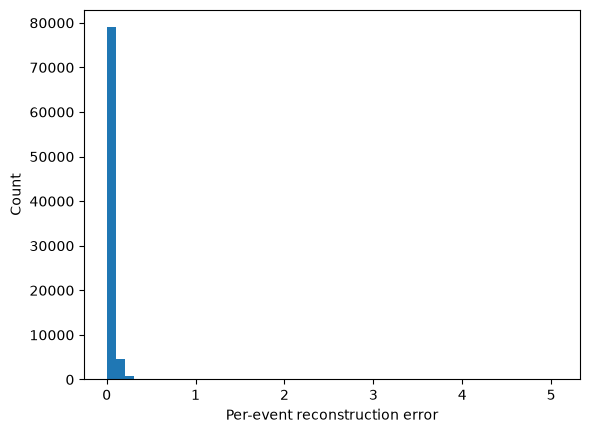

In [57]:
def reconstruction_error(model, X):
    model.eval()
    with torch.inference_mode():
        recon = model(X)
        return ((recon - X) ** 2).mean(dim=1)

test_scores = reconstruction_error(model, X_test)

plt.hist(test_scores.cpu().numpy(), bins=50)
plt.xlabel("Per-event reconstruction error")
plt.ylabel("Count")
plt.show()